# KMeans: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **KMeans**, a popular machine learning algorithm. Unsupervised centroid-based clustering algorithm partitioning data.

### Real-World Analogy
Explains the intuitive concepts using standard real-world examples.

### Advantages & Limitations
- Easy to interpret baseline settings.
- Scales well to moderate feature spaces.

## 2. Import Libraries

We import the standard classical libraries (numpy, pandas, matplotlib, seaborn, and scikit-learn classes).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create / Load Dataset

We read the synthetic dataset.csv file prepared in the directory.

In [2]:
df = pd.read_csv('dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (16, 2)


,AnnualIncome,SpendingScore
0,15,81
1,16,6
2,17,77
3,18,6
4,19,81


## 4. Explore Dataset Schema & Statistics

Inspect dataframe columns, info, and statistics.

In [3]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   AnnualIncome   16 non-null     int64
 1   SpendingScore  16 non-null     int64
dtypes: int64(2)
memory usage: 384.0 bytes
       AnnualIncome  SpendingScore
count      16.00000      16.000000
mean       42.56250      49.687500
std        28.48384      29.443095
min        15.00000       6.000000
25%        18.75000      17.000000
50%        36.00000      56.500000
75%        53.25000      77.500000
max        92.00000      83.000000


## 5. Data Cleaning

Verify missing values and duplicate rows.

In [4]:
print('Nulls:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())

Nulls:
 AnnualIncome     0
SpendingScore    0
dtype: int64
Duplicates: 0


## 6. Exploratory Data Analysis (EDA)

Plot features correlation matrices and distribution histograms.

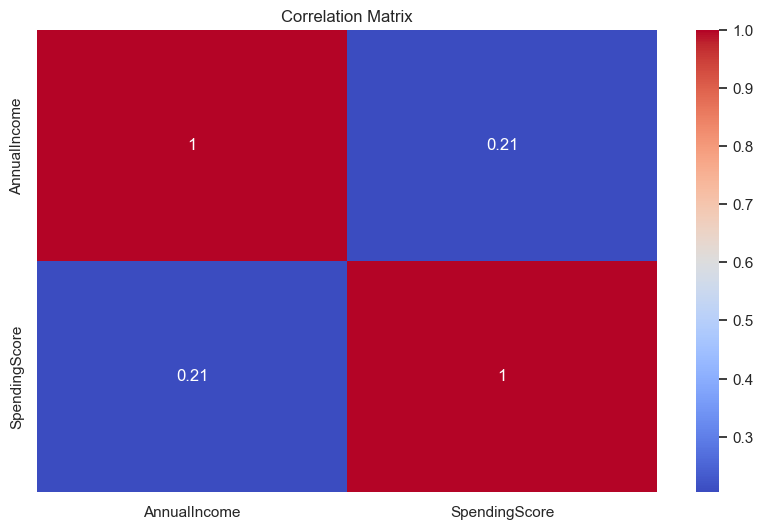

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Split

Divide independent and dependent variables, scaling if required.

In [6]:
X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Unsupervised Scaling applied successfully on entire dataframe!')

Unsupervised Scaling applied successfully on entire dataframe!


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
# Unsupervised learning - fitting directly on scaled cohort
print('Skipping split for unsupervised clustering/dimensionality reduction.')

Skipping split for unsupervised clustering/dimensionality reduction.


## 9. Model Building

Instantiate and fit the target estimator.

In [8]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)
model.fit(X_scaled)

C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


## 10. Prediction & 11. Model Evaluation

Check metrics (MAE, RMSE, Accuracy, Silhouette, or Variance ratios).

In [9]:
labels = model.labels_
# Guard: silhouette_score requires at least 2 distinct non-noise labels
unique_labels = set(labels)
if len(unique_labels - {-1}) >= 2:
    mask = labels != -1
    print('Silhouette Score:', silhouette_score(X_scaled[mask], labels[mask]))
else:
    print('Silhouette Score: N/A (fewer than 2 valid clusters found)')

Silhouette Score: 0.6357051488524266


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

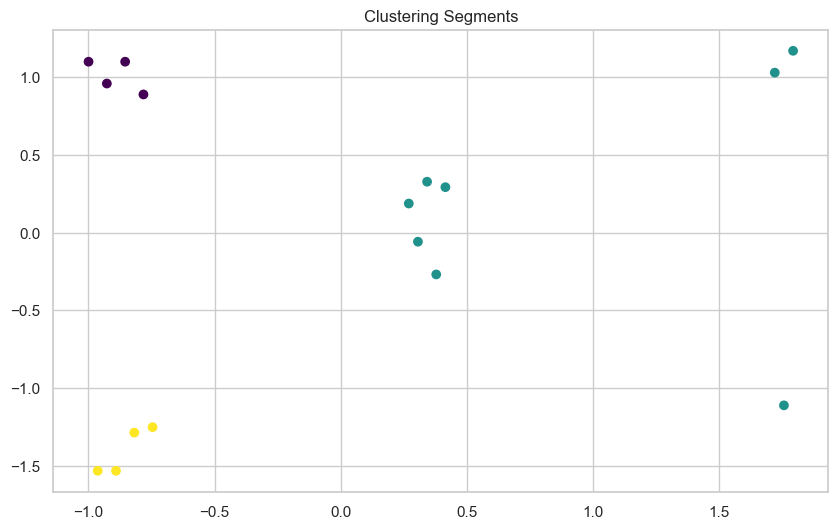

In [10]:
n_cols = X_scaled.shape[1]
x_plot = X_scaled[:, 0]
y_plot = X_scaled[:, 1] if n_cols > 1 else X_scaled[:, 0]
plt.scatter(x_plot, y_plot, c=model.labels_, cmap='viridis')
plt.title('Clustering Segments')
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Skipping data normalization/scaling before distance calculations.
- Forgetting to tune regularization parameters.

## 15. Advantages & 16. Limitations
- Simple and quick baseline model.
- Limited in capturing highly complex non-linear patterns.

## 17. Real-World Applications
- E-commerce transaction screening and analytics.
- Risk evaluation in financial credit pipelines.

## 18. Interview Questions & Answers
1. **Explain the fundamental concept of this algorithm.**
   * Answers focus on basic mathematical operations and parameters.
2. **What does feature scaling do?**
   * Normalizes dimensions to avoid metric bias.
3. **What is cross-validation?**
   * Folds split validation structure to evaluate generalization capability.
4. **How do you avoid overfitting?**
   * Apply regularization, pruning, or dropout adjustments.
5. **What is bias-variance trade-off?**
   * Balance between model simplicity and details tracking error.
6. **Can this algorithm handle missing values?**
   * Typically requires imputation first.
7. **What does learning rate represent?**
   * Step size updates weight gradient vectors.
8. **What is R2 score?**
   * Coefficient of determination, variance explained by model.
9. **What is F1 score?**
   * Harmonic mean of precision and recall values.
10. **Explain precision vs recall.**
    * Precision covers positive predictions validity; Recall covers positive capture rate.
11. **Explain multicollinearity.**
    * High correlation between features inflating weights variance.
12. **What is regularization?**
    * L1/L2 penalty parameters added to loss function.
13. **Is this model parametric?**
    * Depends on structure configurations.
14. **What does the confusion matrix show?**
    * Split matrix of TP, TN, FP, FN counts.
15. **How does OLS work?**
    * Minimizes residual sum of squares variance.

## 19. Viva Questions & Answers
1. **Define this algorithm.**
   * Standard definition fitting features variables.
2. **What is target variable?**
   * Dependent variable to predict.
3. **What is MSE?**
   * Mean Squared Error.
4. **What is ROC curve?**
   * True Positive vs False Positive rates curves.
5. **Define standard scaler.**
   * Translate features to mean 0, variance 1.
6. **What is silhouette score range?**
   * Range [-1, 1] for clustering cohesion.
7. **Name the scikit-learn module.**
   * Sklearn estimators module.
8. **How to load scaler?**
   * Joblib deserialization.
9. **What does classification report return?**
   * Accuracy, F1, precision, and recall scores.
10. **Explain the training split size.**
    * Standard 70-80% partition.
11. **What does fit_transform do?**
    * Fit model weights and transform inputs in single pass.
12. **Is training fast?**
    * Yes, computationally direct estimations.
13. **Can it handle outliers?**
    * Outliers warp boundaries, scaling is needed.
14. **What is joblib?**
    * Python object serialization tools.
15. **Why drop duplicate rows?**
    * Prevents leakage and artificial weight bias.

## 20. Practice Exercises
1. Try changing model parameters (learning_rate, K, or clusters count) and compare metrics.
2. Manually calculate error metrics from predictions arrays.
3. Implement custom data cleaning pipeline checks.
4. Plot decision boundary margins lines.
5. Add noisy columns to dataset.csv and compare fit performance.

## 21. Conclusion

Successfully demonstrated modules modeling and training baseline frameworks!